# GRA: EWC + cifar

project = ```GRA```, host = ```chewie```, device = ```cuda:0```

## Goals:

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Main

In [3]:
from optimzers import *
from test.test import *


def make_opt(opt_class, opt_kws: dict = None, memory_kws: dict = None):
    def _fn(params):
        opt = opt_class(params, **opt_kws)
        if memory_kws is not None:
            opt = RelativisticMemoryOptimizer(
                base_optimizer=opt, **memory_kws)
        return opt
    return _fn

### CIFAR10

`batch_size=256`

In [9]:
cfg = TrainConfig(
    dataset='CIFAR10',
    # dataset='ImageNet32',
    batch_size=256,
    epochs=200,
    device=device,
    data_on_device=True,
    verbose=True,
    amp=False,
)

In [10]:
opt_kws = dict(lr=1e-3, mass=100, betas=(0.8, 0.99))
memory_kws = dict(coupling_strength=1.0, memory_timescale=0.1)


experiments = [
    Experiment(
        name=f"Rel Lion + Memory",
        opt_fn=make_opt(RelativisticLion, opt_kws=opt_kws, memory_kws=memory_kws)),
    Experiment(
        name=f"Rel Lion",
        opt_fn=make_opt(RelativisticLion, opt_kws=opt_kws, memory_kws=None)),
]

print(experiments)

[
    Experiment(name='Rel Lion + Memory', opt_fn=<function make_opt.<locals>._fn at 0x7046fe3af2e0>),
    Experiment(name='Rel Lion', opt_fn=<function make_opt.<locals>._fn at 0x7046fe3af100>)
]

In [11]:
results = run_experiments(experiments, cfg=cfg, seeds=[0])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: RelativisticMemoryOptimizer

RelativisticMemoryOptimizer (
Parameter Group 0
    betas: (0.8, 0.99)
    lr: 0.001
    mass: 100
    weight_decay: 0.0
)

Epoch    1/200:  Train Loss 1.2682  |  Test Acc 64.30%

Epoch    5/200:  Train Loss 0.4427  |  Test Acc 81.18%

Epoch   10/200:  Train Loss 0.2112  |  Test Acc 85.62%

...

Epoch  185/200:  Train Loss 0.0021  |  Test Acc 89.31%

Epoch  190/200:  Train Loss 0.0025  |  Test Acc 88.98%

Epoch  195/200:  Train Loss 0.0026  |  Test Acc 88.63%

Epoch  200/200:  Train Loss 0.0015  |  Test Acc 88.88%

Finished in 671.7s

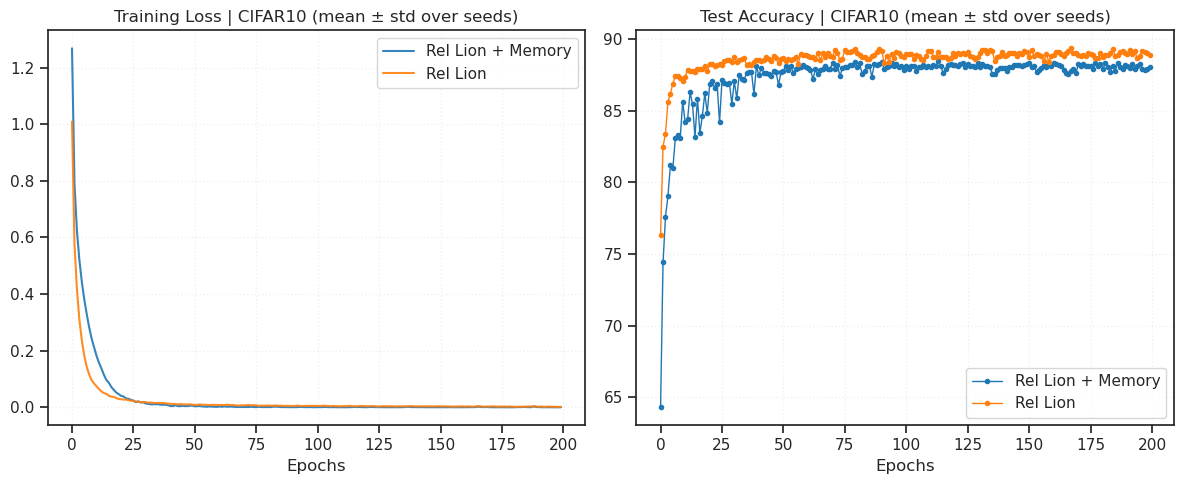

In [12]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)")

In [13]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Rel Lion + Memory': 87.98, 'Rel Lion': 88.97}

### ImageNet32

`batch_size=256`

In [14]:
cfg = TrainConfig(
    dataset='ImageNet32',
    batch_size=256,
    epochs=100,
    device=device,
    data_on_device=False,
    verbose=True,
    amp=False,
)

In [15]:
opt_kws = dict(lr=1e-3, mass=100, betas=(0.8, 0.99))
memory_kws = dict(coupling_strength=1.0, memory_timescale=0.1)


experiments = [
    Experiment(
        name=f"Rel Lion + Memory",
        opt_fn=make_opt(RelativisticLion, opt_kws=opt_kws, memory_kws=memory_kws)),
    Experiment(
        name=f"Rel Lion",
        opt_fn=make_opt(RelativisticLion, opt_kws=opt_kws, memory_kws=None)),
]

print(experiments)

[
    Experiment(name='Rel Lion + Memory', opt_fn=<function make_opt.<locals>._fn at 0x7046fe2f2f20>),
    Experiment(name='Rel Lion', opt_fn=<function make_opt.<locals>._fn at 0x7046fe2f02c0>)
]

In [16]:
results = run_experiments(
    experiments=experiments,
    cfg=cfg,
    model_class=ResNet18,
    model_kws=dict(num_classes=1000),
    seeds=[0],
)

--- Training (ImageNet32) ---

Model: ResNet18({'num_classes': 1000}) | seed=0
Optimizer: RelativisticMemoryOptimizer

RelativisticMemoryOptimizer (
Parameter Group 0
    betas: (0.8, 0.99)
    lr: 0.001
    mass: 100
    weight_decay: 0.0
)

Epoch    1/100:  Train Loss 5.4199  |  Test Acc 9.92%

Epoch    5/100:  Train Loss 3.0106  |  Test Acc 26.54%

Epoch   10/100:  Train Loss 2.1650  |  Test Acc 32.08%

...

Epoch   85/100:  Train Loss 0.0124  |  Test Acc 35.42%

Epoch   90/100:  Train Loss 0.0101  |  Test Acc 35.39%

Epoch   95/100:  Train Loss 0.0082  |  Test Acc 35.52%

Epoch  100/100:  Train Loss 0.0073  |  Test Acc 35.35%

Finished in 15478.2s

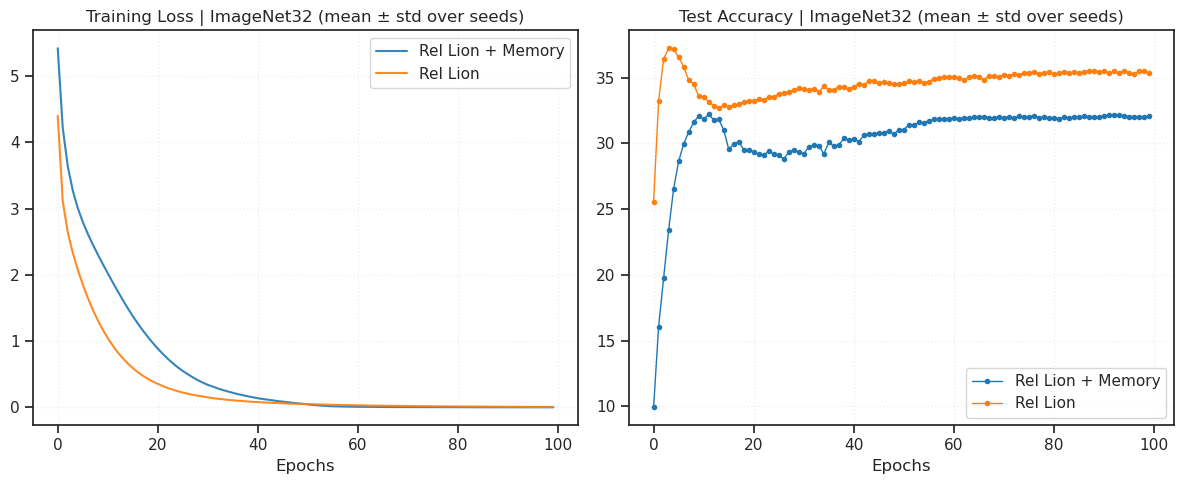

In [17]:
plot_results(results, title="ImageNet32 (mean ± std over seeds)")

In [18]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Rel Lion + Memory': 32.03, 'Rel Lion': 35.39}